In [1]:
import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import os
from IPython.display import display, HTML
import matplotlib.patheffects as PathEffects

# --- CONFIGURATION ---
DB_PATH = "db/results.sqlite" 
sns.set_theme(style="whitegrid", context="paper")

In [2]:
# --- CUSTOM CSS FOR DASHBOARD ---
DASHBOARD_CSS = """
<style>
    :root {
        --bg-color: #ffffff;
        --text-color: #2c3e50;
        --accent: #3498db;
        --border: #e0e0e0;
        --success: #27ae60;
        --warning: #f39c12;
        --danger: #c0392b;
    }
    .db-container { font-family: 'Segoe UI', sans-serif; max-width: 100%; color: var(--text-color); }
    .db-header { background: #f8f9fa; padding: 15px; border-bottom: 2px solid var(--accent); margin-bottom: 20px; }
    .db-stat-grid { display: grid; grid-template-columns: repeat(auto-fit, minmax(120px, 1fr)); gap: 10px; margin-bottom: 20px; }
    .db-stat-card { background: #fff; border: 1px solid var(--border); padding: 10px; text-align: center; border-radius: 4px; box-shadow: 0 1px 3px rgba(0,0,0,0.05); }
    .db-stat-val { font-size: 1.2em; font-weight: bold; }
    .db-stat-label { font-size: 0.8em; color: #7f8c8d; text-transform: uppercase; }
    .cluster-card { border: 1px solid var(--border); margin-bottom: 25px; border-radius: 6px; overflow: hidden; box-shadow: 0 2px 5px rgba(0,0,0,0.05); }
    .cluster-head { padding: 10px 15px; display: flex; justify-content: space-between; align-items: center; background: #f1f2f6; border-bottom: 1px solid var(--border); }
    .cluster-title { font-weight: bold; font-size: 1.1em; }
    .acc-container { display: flex; align-items: center; gap: 10px; }
    .acc-bar-bg { width: 100px; height: 8px; background: #ddd; border-radius: 4px; overflow: hidden; }
    .acc-bar-fill { height: 100%; transition: width 0.3s; }
    .metric-table { width: 100%; border-collapse: collapse; font-size: 0.9em; margin: 10px 0; }
    .metric-table th { text-align: left; padding: 8px; border-bottom: 1px solid #ddd; color: #7f8c8d; }
    .metric-table td { padding: 8px; border-bottom: 1px solid #eee; }
    .shift-bar-container { width: 100px; height: 6px; background: #eee; position: relative; border-radius: 2px; }
    .shift-bar { height: 100%; position: absolute; top: 0; }
    details { margin: 0; border-top: 1px solid #eee; }
    summary { padding: 10px 15px; cursor: pointer; background: #fff; font-weight: 500; color: var(--accent); user-select: none; }
    summary:hover { background: #f8f9fa; }
    .ex-content { padding: 15px; background: #fafafa; border-top: 1px solid #eee; font-family: monospace; white-space: pre-wrap; font-size: 0.85em; max-height: 400px; overflow-y: auto; }
    .status-badge-pass { background: var(--success); color: white; padding: 2px 6px; border-radius: 4px; font-size: 0.75em; vertical-align: middle; }
    .status-badge-fail { background: var(--danger); color: white; padding: 2px 6px; border-radius: 4px; font-size: 0.75em; vertical-align: middle; }
    .gold-box { border-left: 3px solid var(--success); padding-left: 10px; margin: 5px 0; color: #444; background: rgba(39, 174, 96, 0.05); padding: 5px; }
    .pred-box { border-left: 3px solid var(--accent); padding-left: 10px; margin: 5px 0; color: #444; background: rgba(52, 152, 219, 0.05); padding: 5px; }
</style>
"""

def generate_cluster_html(c_id, count, acc, metrics_html, examples_html):
    if acc >= 80: acc_color = "var(--success)"
    elif acc >= 50: acc_color = "var(--warning)"
    else: acc_color = "var(--danger)"
    
    return f"""
    <div class="cluster-card">
        <div class="cluster-head" style="border-left: 5px solid {acc_color}">
            <div class="cluster-title">CLUSTER {c_id}</div>
            <div class="acc-container">
                <span style="font-size: 0.9em; font-weight: bold;">{acc:.1f}% Acc</span>
                <div class="acc-bar-bg"><div class="acc-bar-fill" style="width: {acc}%; background: {acc_color};"></div></div>
                <span style="font-size: 0.8em; color: #666;">({count} Samples)</span>
            </div>
        </div>
        <div style="padding: 15px;">
            <table class="metric-table">
                <thead><tr><th>Metric</th><th>Shift (SD)</th><th>Mean</th><th>SD</th><th>Vis</th></tr></thead>
                <tbody>{metrics_html}</tbody>
            </table>
        </div>
        <details>
            <summary>View Representative Examples ({count})</summary>
            <div class="ex-content">{examples_html}</div>
        </details>
    </div>
    """

In [3]:
def load_latest_data(db_path):
    if not os.path.exists(db_path):
        print(f"❌ Database not found at {db_path}")
        return None, None

    conn = sqlite3.connect(db_path)
    
    # 1. Get Latest Experiment
    exp_query = "SELECT experiment_id, name FROM Experiments ORDER BY experiment_id DESC LIMIT 1"
    try:
        exp_df = pd.read_sql(exp_query, conn)
        if exp_df.empty: return None, None
        latest_exp = exp_df.iloc[0]
        latest_id, name = latest_exp['experiment_id'], latest_exp['name']
    except Exception as e:
        print(f"Error finding experiment: {e}")
        return None, None

    print(latest_id)
    # 2. Get Results
    res_query = f"""
    SELECT r.result_id, r.question_id_external, r.question_text, r.gold_answer, 
           r.predicted_answer, r.full_trace_text, r.is_correct,
           r.uq_avg_entropy as 'Entropy', r.uq_min_logit_gap as 'LogitGap',
           r.uq_heuristic_score as 'Heuristic', r.uq_mech_score as 'Mechanistic'
    FROM Results r WHERE r.experiment_id = {latest_id}
    """
    
    try:
        df = pd.read_sql(res_query, conn)
        conn.close()
        
        if df.empty: return None, latest_id
        df['Correct'] = df['is_correct'].astype(int)
        
        # 3. Calculate Semantic Entropy (On-the-fly)
        def calc_semantic_entropy(sub):
            answers = sub['predicted_answer'].fillna("").str.strip().str.lower()
            probs = answers.value_counts(normalize=True)
            return -np.sum(probs * np.log(probs + 1e-10))

        if 'question_id_external' in df.columns:
            # Handle newer pandas groupby behavior
            try:
                se_map = df.groupby('question_id_external').apply(calc_semantic_entropy, include_groups=False)
            except TypeError:
                se_map = df.groupby('question_id_external').apply(calc_semantic_entropy)
            df['Semantic'] = df['question_id_external'].map(se_map)
        else:
            df['Semantic'] = 0.0

        df['Length'] = df['full_trace_text'].fillna("").str.len()
            
        return df, (latest_id, name)
            
    except Exception as e:
        print(f"Error processing results: {e}")
        if conn: conn.close()
        return None, None

In [4]:
def get_magnitude_desc(z_score):
    if z_score > 3.0:  return "Very High"
    elif z_score > 1.5: return "High"
    elif z_score > 0.5: return "Elevated"
    elif z_score < -3.0: return "Very Low"
    elif z_score < -1.5: return "Low"
    elif z_score < -0.5: return "Reduced"
    return None

def generate_label(sub_df, features, global_means, global_sds):
    acc = (sub_df['Correct'].sum() / len(sub_df)) * 100
    
    descriptions = []
    for f in features:
        if global_sds[f] == 0: continue
        z_val = (sub_df[f].mean() - global_means[f]) / global_sds[f]
        desc = get_magnitude_desc(z_val)
        if desc:
            descriptions.append((abs(z_val), f"{desc} {f}"))
            
    descriptions.sort(key=lambda x: x[0], reverse=True)
    top_descs = [d[1] for d in descriptions[:3]]
    
    chars = "\n".join(top_descs) if top_descs else "Average Stats"
    return f"N {str(len(sub_df))}, Acc: {acc:.1f}%\n{chars}"

1


Metric,Shift (SD),Mean,SD,Vis
Entropy,+0.11 SD,0.065,0.017,
LogitGap,+0.09 SD,0.047,0.041,
Heuristic,+0.84 SD,0.482,0.027,
Mechanistic,+0.23 SD,0.969,0.005,
Metric,Shift (SD),Mean,SD,Vis
Entropy,-0.56 SD,0.040,0.018,
LogitGap,+2.70 SD,0.245,0.090,
Heuristic,-0.06 SD,0.445,0.036,
Mechanistic,-0.82 SD,0.960,0.008,
Metric,Shift (SD),Mean,SD,Vis


Generating t-SNE...


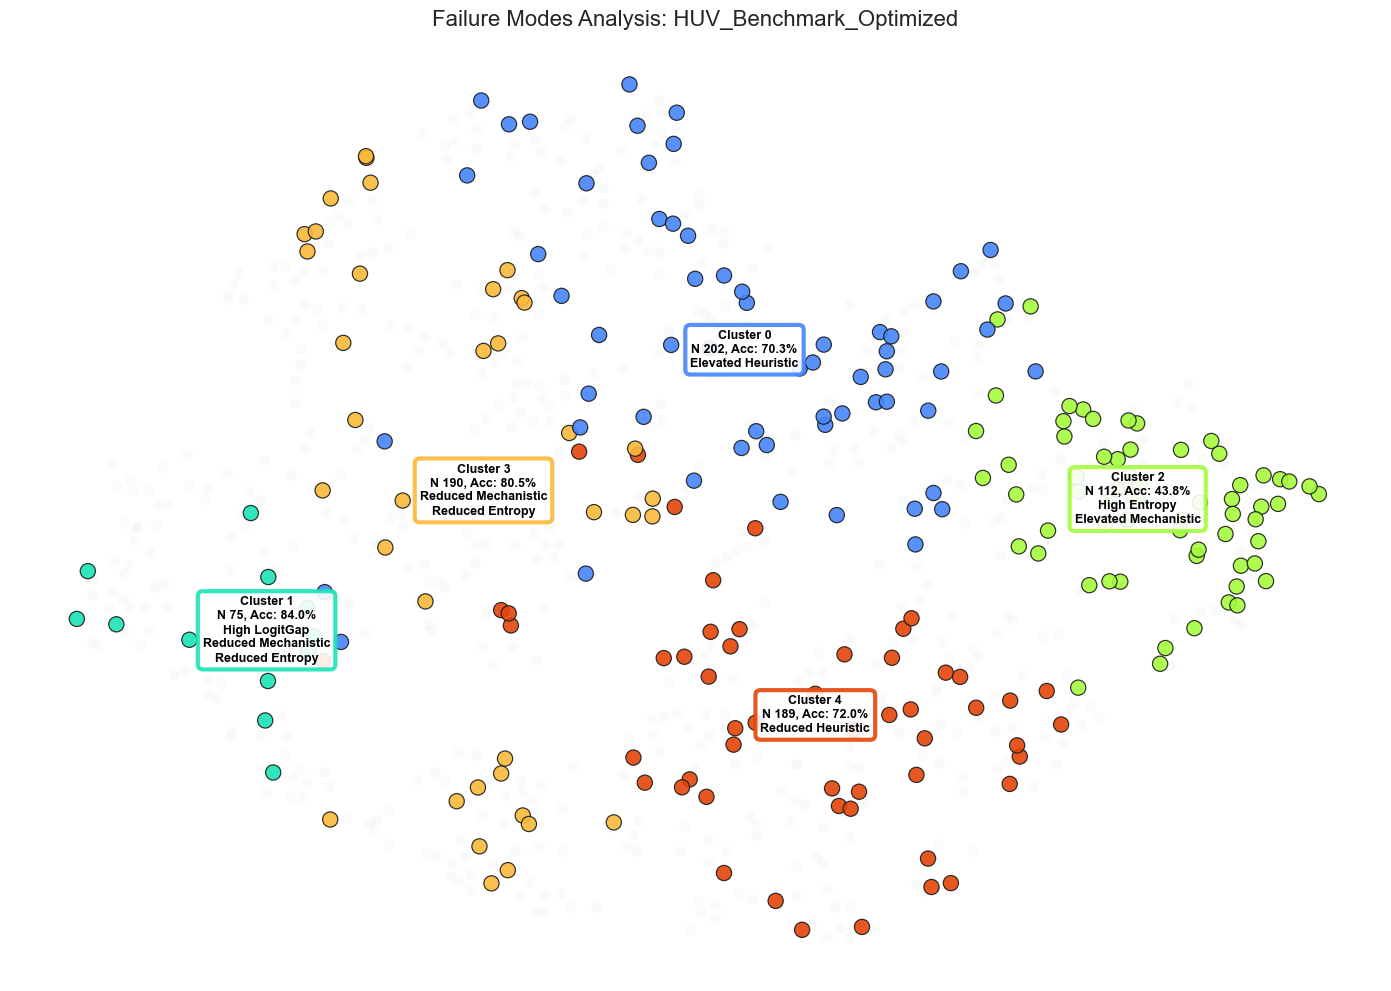

In [5]:
# Load Data
df, EXP_INFO = load_latest_data(DB_PATH)

if df is not None:
    exp_id, exp_name = EXP_INFO
    
    # --- 1. CLUSTERING ---
    features = ['Entropy', 'LogitGap', 'Heuristic', 'Mechanistic', ] # 'Semantic', "Length"
    X = StandardScaler().fit_transform(df[features].fillna(0))
    kmeans = KMeans(n_clusters=5, random_state=42, n_init=5)
    df['Cluster'] = kmeans.fit_predict(X)

    # --- 2. HTML DASHBOARD ---
    global_medians = df[features].median()
    global_sds = df[features].std()
    
    html_out = [DASHBOARD_CSS, f'<div class="db-container">']
    html_out.append(f'<div class="db-header"><h2>Run: {exp_name} (ID: {exp_id})</h2><small>{len(df)} samples</small></div>')

    # Global Stats
    stat_cards = "".join([f'<div class="db-stat-card"><div class="db-stat-val">{global_medians[f]:.3f}</div><div class="db-stat-label">{f}</div></div>' for f in features])
    html_out.append(f'<div class="db-stat-grid">{stat_cards}</div>')

    # Per Cluster Stats
    for c in sorted(df['Cluster'].unique()):
        sub = df[df['Cluster'] == c]
        n_total = len(sub)
        acc = (sub['Correct'].sum() / n_total) * 100
        
        metrics_rows = ""
        for f in features:
            mu, sd = sub[f].mean(), sub[f].std()
            shift_val = (mu - global_medians[f]) / global_sds[f] if global_sds[f] != 0 else 0
            
            bar_color = "#c0392b" if shift_val > 1.0 else ("#2980b9" if shift_val < -1.0 else "#95a5a6")
            vis_width = min(abs(shift_val) * 15, 50) 
            vis_left = "50%" if shift_val > 0 else f"{50 - vis_width}%"
            
            metrics_rows += f"""<tr><td><b>{f}</b></td><td style="color:{bar_color}">{shift_val:+.2f} SD</td><td>{mu:.3f}</td><td>{sd:.3f}</td>
                <td><div class="shift-bar-container"><div class="shift-bar" style="left:50%; width:1px; background:#ccc;"></div><div class="shift-bar" style="left:{vis_left}; width:{vis_width}%; background:{bar_color}; opacity:0.8;"></div></div></td></tr>"""
        
        # Example Rows (Subset)
        ex_rows = ""
        for i, (_, row) in enumerate(sub.head(5).iterrows()):
            badge = '<span class="status-badge-pass">✅ Correct</span>' if row['Correct'] else '<span class="status-badge-fail">❌ Incorrect</span>'
            ex_rows += f'<div style="margin-bottom:10px;"><strong>[Ex {i+1}] {badge}</strong><br>Q: {row.get("question_text")}<br><div class="pred-box">Pred: {row.get("full_trace_text")}</div></div><hr>'
            
        html_out.append(generate_cluster_html(c, n_total, acc, metrics_rows, ex_rows))
        
    html_out.append("</div>")
    display(HTML("".join(html_out)))

    # --- 3. GRAPHING (COLOR-CODED LABELS) ---
    print("Generating t-SNE...")
    tsne = TSNE(n_components=2, perplexity=min(30, len(df)-1), random_state=42, init='pca')
    proj = tsne.fit_transform(X)
    df['x'], df['y'] = proj[:, 0], proj[:, 1]
    
    # Create explicit color map to ensure labels match points
    unique_clusters = sorted(df['Cluster'].unique())
    # Use 'turbo' palette, getting exactly N distinct colors
    palette_colors = sns.color_palette("turbo", n_colors=len(unique_clusters))
    cluster_cmap = dict(zip(unique_clusters, palette_colors))

    global_means = df[features].mean() # For labeling logic

    plt.figure(figsize=(14, 10))

    # A. Background (Correct)
    sns.scatterplot(
        data=df[df['Correct']==1], x='x', y='y', 
        color='#ecf0f1', s=60, alpha=0.3, linewidth=0, zorder=0
    )

    # B. Foreground (Incorrect/Clusters) - using explicit palette
    sns.scatterplot(
        data=df[df['Correct']==0], x='x', y='y', 
        hue='Cluster', palette=cluster_cmap, 
        s=120, alpha=0.9, edgecolor='k', legend=False, zorder=10
    )

    # C. Labels with Matching Colors
    for c in unique_clusters:
        sub = df[df['Cluster'] == c]
        failures = sub[sub['Correct'] == 0]
        
        # Determine label position (center of failures if possible)
        target = failures if len(failures) > 3 else sub
        if len(target) == 0: continue
            
        cx, cy = target['x'].median(), target['y'].median()
        label_text = f"Cluster {c}\n" + generate_label(sub, features, global_means, global_sds)
        
        # Get color for this cluster
        c_color = cluster_cmap[c]
        
        # Add Label: White Box with Colored Border matching the cluster
        plt.text(
            cx, cy, label_text, 
            horizontalalignment='center', verticalalignment='center',
            fontsize=9, fontweight='bold', color='black',
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=c_color, lw=3, alpha=0.9),
            zorder=20
        )

    plt.title(f"Failure Modes Analysis: {exp_name}", fontsize=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

else:
    print("❌ Script aborted due to missing data.")

In [13]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# --- 1. UNPACK THE JSON TRACES ---
# We explode the lists so every row is ONE generated token
display(Markdown("### Processing Token Traces from DB..."))

# Helper to safely parse JSON columns
def safe_parse(val):
    try:
        return json.loads(val)
    except (TypeError, json.JSONDecodeError):
        return []

# Apply parsing
df['tokens'] = df['uq_tokens'].apply(safe_parse)
df['entropy'] = df['uq_entropy_trace'].apply(safe_parse)
df['logit_gap'] = df['uq_logit_gap_trace'].apply(safe_parse)

# Create a "Long" DataFrame: One row per GENERATED token
# We zip tokens, entropy, and logit_gap together
token_rows = []
for idx, row in df.iterrows():
    # Ensure all lists are same length to avoid errors
    length = min(len(row['tokens']), len(row['entropy']), len(row['logit_gap']))
    
    for i in range(length):
        token_rows.append({
            'question_id': idx,
            'token_pos': i,
            'token': row['tokens'][i],
            'entropy': row['entropy'][i],
            'logit_gap': row['logit_gap'][i],
            'is_correct': row['Correct'] # Inherit label from parent question
        })

token_df = pd.DataFrame(token_rows)
display(Markdown(f"Expanded **{len(df)}** questions into **{len(token_df)}** individual tokens."))

# --- 2. IDENTIFY THE "CONFUSION" TOKENS ---
# Which specific tokens typically appear with High Entropy?

# Group by Token and calculate metrics
# Filter: Only look at tokens that appear at least 10 times to avoid noise
token_stats = token_df.groupby('token').agg({
    'entropy': 'mean',
    'logit_gap': 'mean',
    'question_id': 'count' # Frequency
}).rename(columns={'question_id': 'count'})

token_stats = token_stats[token_stats['count'] >= 10].sort_values('entropy', ascending=False)

display(Markdown("### 1. The 'Confusion' Dictionary"))
display(Markdown("These are the **generated words** where the model is most uncertain."))

# Display Top 10 High Entropy Tokens
display(token_stats.head(10).style.background_gradient(cmap='Reds', subset=['entropy']))

# --- 3. VISUALIZATION: DO NUMBERS CONFUSE THE MODEL? ---
# Let's check if numerical tokens have higher entropy than text tokens

def is_number(s):
    try:
        float(s.strip())
        return True
    except:
        return False

token_df['is_number'] = token_df['token'].apply(is_number)

plt.figure(figsize=(10, 5))
sns.boxplot(x='is_number', y='entropy', data=token_df, showfliers=False, palette="Set2")
plt.title("Uncertainty: Numbers vs. Words")
plt.xlabel("Is Token a Number?")
plt.ylabel("Token Entropy")
plt.xticks([0, 1], ['Text', 'Number'])
plt.show()

# --- 4. POSITION ANALYSIS ---
# Does entropy spike at the start or end of the sentence?
plt.figure(figsize=(10, 5))
sns.lineplot(x='token_pos', y='entropy', hue='is_correct', data=token_df[token_df['token_pos'] < 50])
plt.title("Entropy Trace over Generation Length")
plt.xlabel("Token Position")
plt.ylabel("Average Entropy")
plt.legend(title="Final Answer Correct?")
plt.show()

### Processing Token Traces from DB...

KeyError: 'uq_tokens'

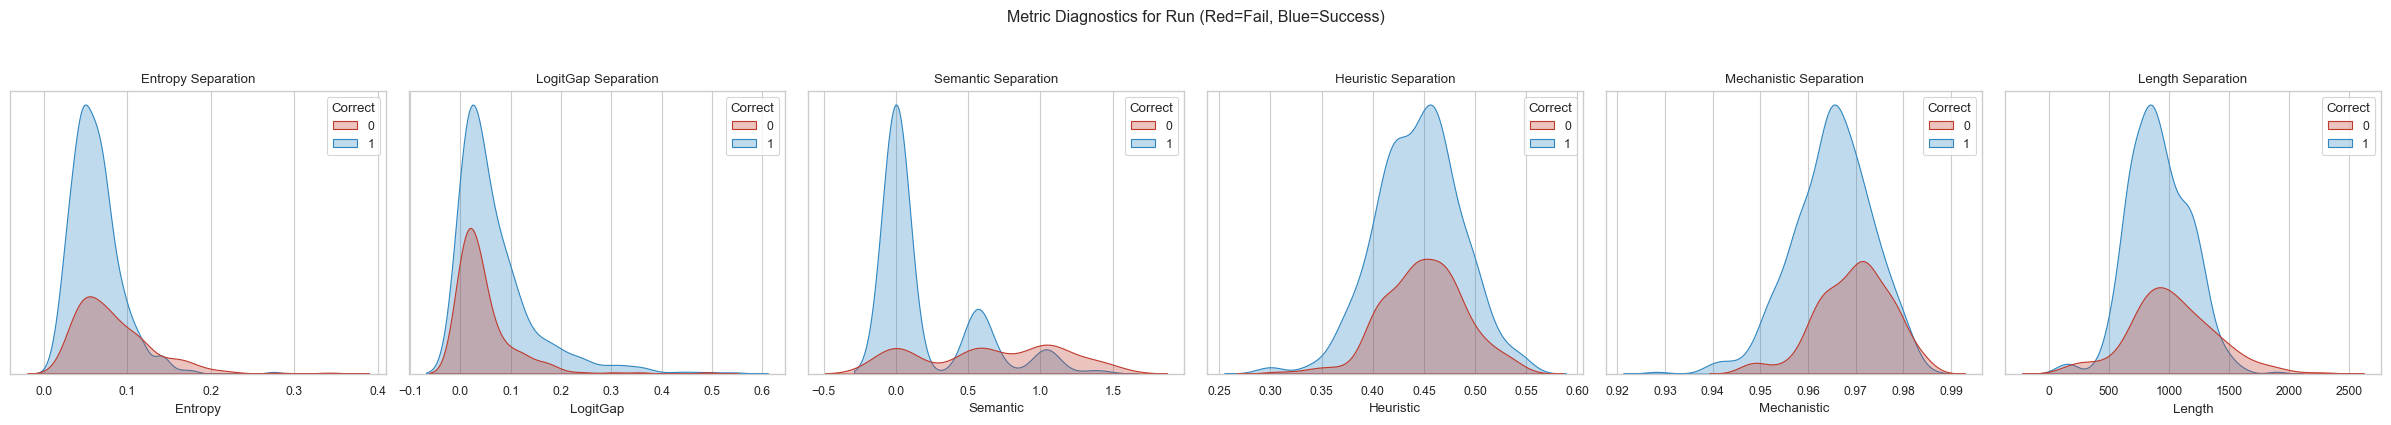

In [6]:
# Select only metrics that have data (variance > 0)
metrics = [m for m in ['Entropy', 'LogitGap', 'Semantic', 'Heuristic', 'Mechanistic', "Length"] 
           if df[m].var() > 1e-5]

fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 4))
if len(metrics) == 1: axes = [axes]

for i, m in enumerate(metrics):
    # Plot KDE (Smooth Histogram)
    sns.kdeplot(
        data=df, x=m, hue='Correct', 
        fill=True, palette={0: "#C0392B", 1: "#2E86C1"}, 
        alpha=0.3, warn_singular=False, ax=axes[i]
    )
    axes[i].set_title(f"{m} Separation")
    axes[i].set_ylabel("")
    axes[i].get_yaxis().set_ticks([]) # Clean look

plt.suptitle(f"Metric Diagnostics for Run (Red=Fail, Blue=Success)", y=1.05)
plt.tight_layout()
plt.show()

### 1. Feature Subset Analysis

We tested **31 combinations**. Below are the top 10 performing subsets.

,Num_Features,Features,AUC,% of Max
0,3,"Entropy, Heuristic, Mechanistic",0.6887,100.0%
1,3,"Entropy, LogitGap, Heuristic",0.6834,99.2%
2,2,"Entropy, Mechanistic",0.6830,99.2%
3,2,"Entropy, Heuristic",0.6778,98.4%
4,2,"Entropy, LogitGap",0.6740,97.9%
5,4,"Entropy, LogitGap, Heuristic, Mechanistic",0.6728,97.7%
6,2,"Heuristic, Mechanistic",0.6699,97.3%
7,3,"Entropy, LogitGap, Mechanistic",0.6682,97.0%
8,1,Entropy,0.6671,96.9%
9,3,"LogitGap, Heuristic, Mechanistic",0.6647,96.5%


### 2. Full Model Weights (Drivers)

/var/folders/q0/hw11rnjs0g1cnny7p5swsnv40000gn/T/ipykernel_66987/2646675840.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Weight', y='Feature', data=coef_df, palette=colors)


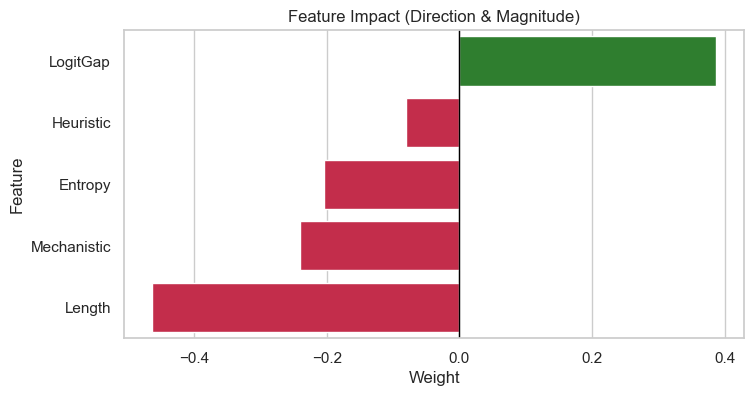

### 3. Complexity vs. Performance

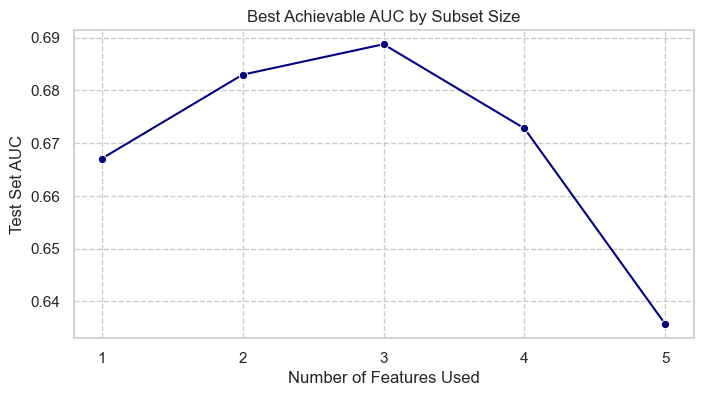

**Classification Report (Full Model):**

              precision    recall  f1-score   support

           0      0.382     0.607     0.469       117
           1      0.768     0.569     0.654       267

    accuracy                          0.581       384
   macro avg      0.575     0.588     0.561       384
weighted avg      0.650     0.581     0.597       384



In [7]:
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

# Setup
sns.set_theme(style="whitegrid")
features = ['Entropy', 'LogitGap', 'Heuristic', 'Mechanistic', "Length"]

# 1. PREP & SPLIT
train_q, test_q = train_test_split(df['question_text'].unique(), test_size=0.5, random_state=42)
train_df = df[df['question_text'].isin(train_q)].copy().fillna(0)
test_df  = df[df['question_text'].isin(test_q)].copy().fillna(0)
y_train, y_test = train_df['Correct'], test_df['Correct']

# Scale global (fit on train, transform test)
scaler = StandardScaler()
X_train_full = pd.DataFrame(scaler.fit_transform(train_df[features]), columns=features)
X_test_full  = pd.DataFrame(scaler.transform(test_df[features]), columns=features)

# --- 2. SUBSET SEARCH (Find the "Best" Combination) ---
results = []
# Loop through all combinations of features (size 1 to 5)
for r in range(1, len(features) + 1):
    for subset in itertools.combinations(features, r):
        cols = list(subset)
        
        # Train simple LR
        clf = LogisticRegression(class_weight="balanced", random_state=42, penalty='l2')
        clf.fit(X_train_full[cols], y_train)
        
        # Score
        probs = clf.predict_proba(X_test_full[cols])[:, 1]
        auc = roc_auc_score(y_test, probs)
        
        results.append({
            'Num_Features': len(cols),
            'Features': ", ".join(cols),
            'AUC': auc
        })

# Rank Results
res_df = pd.DataFrame(results).sort_values('AUC', ascending=False).reset_index(drop=True)
best_auc = res_df.iloc[0]['AUC']
res_df['% of Max'] = (res_df['AUC'] / best_auc)

# --- 3. REPORTING ---

display(Markdown("### 1. Feature Subset Analysis"))
display(Markdown(f"We tested **{len(res_df)} combinations**. Below are the top 10 performing subsets."))

# Show Top 5 Subsets
display(
    res_df.head(10).style.bar(subset=['AUC'], color='#5fba7d', vmin=0.5, vmax=1.0)
    .format("{:.4f}", subset=['AUC'])
    .format("{:.1%}", subset=['% of Max'])
)

# --- 4. FULL MODEL INTERPRETABILITY ---
display(Markdown("### 2. Full Model Weights (Drivers)"))

# Retrain full model for coefficients
clf_full = LogisticRegression(class_weight="balanced", random_state=42)
clf_full.fit(X_train_full, y_train)

coef_df = pd.DataFrame({
    'Feature': features,
    'Weight': clf_full.coef_[0],
    'Odds Ratio': np.exp(clf_full.coef_[0])
}).sort_values(by='Weight', ascending=False)

# Plot Weights
plt.figure(figsize=(8, 4))
colors = ['forestgreen' if x > 0 else 'crimson' for x in coef_df['Weight']]
sns.barplot(x='Weight', y='Feature', data=coef_df, palette=colors)
plt.title("Feature Impact (Direction & Magnitude)")
plt.axvline(0, color='black', lw=1)
plt.show()

# --- 5. VISUALIZING TRADE-OFFS ---
display(Markdown("### 3. Complexity vs. Performance"))

# Plot AUC vs Number of Features
plt.figure(figsize=(8, 4))
sns.lineplot(x='Num_Features', y='AUC', data=res_df, marker='o', estimator='max', errorbar=None, color='navy')
plt.title("Best Achievable AUC by Subset Size")
plt.ylabel("Test Set AUC")
plt.xlabel("Number of Features Used")
plt.xticks(range(1, 6))
plt.grid(True, linestyle='--')
plt.show()

# Final Simple Classification Report (Full Model)
display(Markdown("**Classification Report (Full Model):**"))
preds = clf_full.predict(X_test_full)
print(classification_report(y_test, preds, digits=3))

### 1. Feature Importance (Weights & Odds Ratios)

**Interpretation:** <br>- **Positive Weight:** Increases probability of 'Correct'.<br>- **Odds Ratio:** Multiplicative change in odds for 1-std-dev increase.

,Feature,Weight (Log-Odds),Odds Ratio,Abs Impact
4,Length,-0.4627,0.6296,0.4627
1,LogitGap,0.3868,1.4723,0.3868
3,Mechanistic,-0.2401,0.7865,0.2401
0,Entropy,-0.2041,0.8154,0.2041
2,Heuristic,-0.0803,0.9228,0.0803


/var/folders/q0/hw11rnjs0g1cnny7p5swsnv40000gn/T/ipykernel_66987/615998586.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Weight (Log-Odds)', y='Feature', data=coef_df, palette=colors)


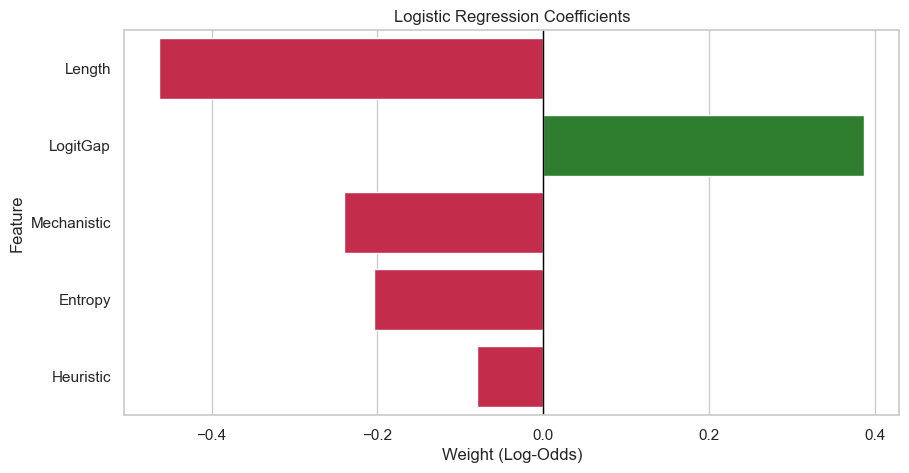

---

### 2. Individual Metric Performance

,Feature,Univariate AUC,Predictive Power
0,Entropy,0.3329,0.6671
3,Mechanistic,0.3359,0.6641
1,LogitGap,0.5975,0.5975
2,Heuristic,0.4316,0.5684
4,Length,0.4610,0.5390


/var/folders/q0/hw11rnjs0g1cnny7p5swsnv40000gn/T/ipykernel_66987/615998586.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Correct', y=feat, data=test_df, ax=axes[i], palette="Set2")
/var/folders/q0/hw11rnjs0g1cnny7p5swsnv40000gn/T/ipykernel_66987/615998586.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Correct', y=feat, data=test_df, ax=axes[i], palette="Set2")
/var/folders/q0/hw11rnjs0g1cnny7p5swsnv40000gn/T/ipykernel_66987/615998586.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Correct', y=feat, data=test_df,

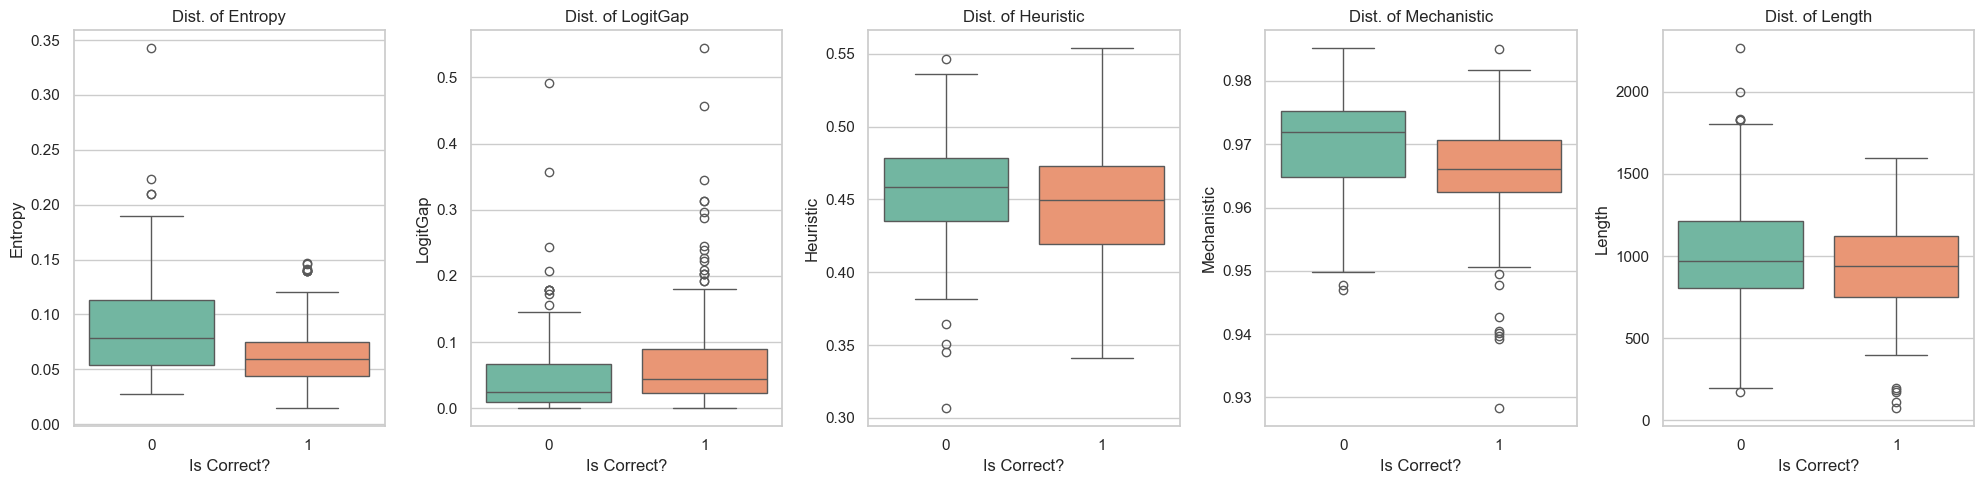

---

### 3. Overall Model Performance

Metric,Value
ROC-AUC,0.6357
Log Loss,0.6832
Brier Score,0.2428
Accuracy,0.5807


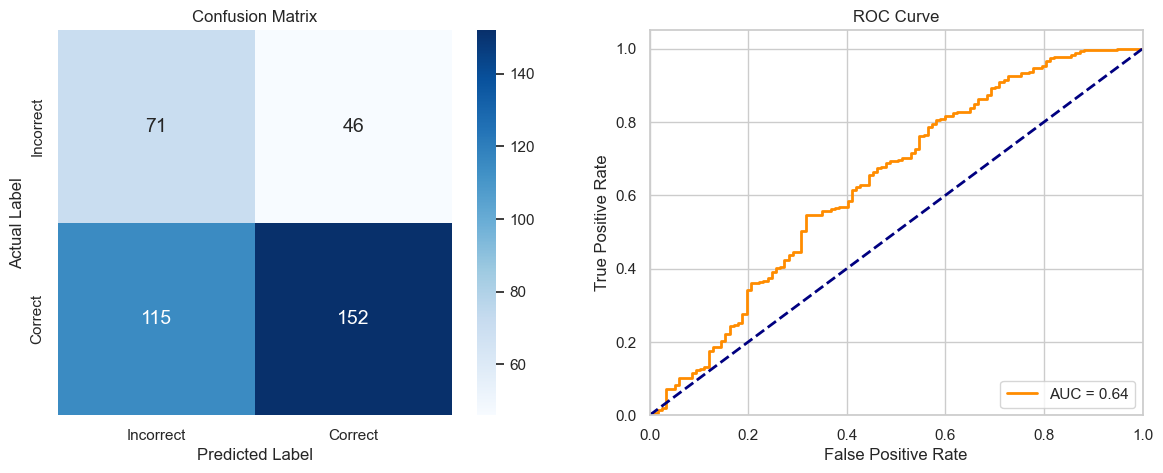

**Detailed Classification Report:**

,precision,recall,f1-score,support
0,0.382,0.607,0.469,117
1,0.768,0.569,0.654,267
accuracy,0.581,0.581,0.581,1
macro avg,0.575,0.588,0.561,384
weighted avg,0.650,0.581,0.597,384


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix, 
    log_loss, brier_score_loss, roc_curve
)

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# --- 1. PREP & SPLIT ---
features = ['Entropy', 'LogitGap', 'Heuristic', 'Mechanistic', "Length"]
unique_questions = df['question_text'].unique()

train_q, test_q = train_test_split(unique_questions, test_size=0.5, random_state=42)
train_df = df[df['question_text'].isin(train_q)].copy()
test_df  = df[df['question_text'].isin(test_q)].copy()

scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[features].fillna(0))
X_test  = scaler.transform(test_df[features].fillna(0))
y_train, y_test = train_df['Correct'], test_df['Correct']

# --- 2. MODEL TRAINING ---
clf = LogisticRegression(
    penalty="l2", C=1.0, class_weight="balanced", 
    max_iter=1000, random_state=42
)
clf.fit(X_train, y_train)

probs = clf.predict_proba(X_test)[:, 1]
test_df['Prob_Correct'] = probs
test_df['Pred_Label'] = (probs > 0.5).astype(int)

# ==============================================================================
# 3. RICH VISUALIZATION & REPORTING (FIXED)
# ==============================================================================

def print_header(text):
    display(Markdown(f"### {text}"))

def print_divider():
    display(Markdown("---"))

# --- PART A: MODEL COEFFICIENTS (WEIGHTS) ---
print_header("1. Feature Importance (Weights & Odds Ratios)")
display(Markdown(
    "**Interpretation:** <br>"
    "- **Positive Weight:** Increases probability of 'Correct'.<br>"
    "- **Odds Ratio:** Multiplicative change in odds for 1-std-dev increase."
))

coef_data = {
    'Feature': features,
    'Weight (Log-Odds)': clf.coef_[0],
    'Odds Ratio': np.exp(clf.coef_[0]),
    'Abs Impact': np.abs(clf.coef_[0])
}
coef_df = pd.DataFrame(coef_data).sort_values(by='Abs Impact', ascending=False)

# [FIX] Use 'subset' to apply float formatting only to numeric columns
display(
    coef_df.style.background_gradient(cmap='coolwarm', subset=['Weight (Log-Odds)'])
    .format("{:.4f}", subset=['Weight (Log-Odds)', 'Odds Ratio', 'Abs Impact'])
)

# Plot
plt.figure(figsize=(10, 5))
colors = ['forestgreen' if x > 0 else 'crimson' for x in coef_df['Weight (Log-Odds)']]
sns.barplot(x='Weight (Log-Odds)', y='Feature', data=coef_df, palette=colors)
plt.title("Logistic Regression Coefficients")
plt.axvline(0, color='black', linewidth=1)
plt.show()

print_divider()

# --- PART B: UNIVARIATE FEATURE EVALUATION ---
print_header("2. Individual Metric Performance")

uni_data = []
for feat in features:
    score = roc_auc_score(y_test, test_df[feat].fillna(0))
    # If AUC < 0.5, flip it to represent predictive power regardless of direction
    power = score if score > 0.5 else 1 - score
    uni_data.append({'Feature': feat, 'Univariate AUC': score, 'Predictive Power': power})

uni_df = pd.DataFrame(uni_data).sort_values('Predictive Power', ascending=False)

# [FIX] Apply formatting strictly to numeric columns
display(
    uni_df.style.bar(subset=['Predictive Power'], color='#5fba7d', vmin=0.5, vmax=1.0)
    .format("{:.4f}", subset=['Univariate AUC', 'Predictive Power'])
)

# Distributions
fig, axes = plt.subplots(1, len(features), figsize=(20, 5))
for i, feat in enumerate(features):
    sns.boxplot(x='Correct', y=feat, data=test_df, ax=axes[i], palette="Set2")
    axes[i].set_title(f"Dist. of {feat}")
    axes[i].set_xlabel("Is Correct?")
plt.tight_layout()
plt.show()

print_divider()

# --- PART C: OVERALL MODEL PERFORMANCE ---
print_header("3. Overall Model Performance")

metrics_df = pd.DataFrame({
    'Metric': ['ROC-AUC', 'Log Loss', 'Brier Score', 'Accuracy'],
    'Value': [
        roc_auc_score(y_test, probs),
        log_loss(y_test, probs),
        brier_score_loss(y_test, probs),
        clf.score(X_test, y_test)
    ]
})
# Dictionary formatting is safe
display(metrics_df.style.hide(axis='index').format({"Value": "{:.4f}"}))

# Charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, test_df['Pred_Label'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, annot_kws={"size": 14})
ax1.set_title("Confusion Matrix")
ax1.set_ylabel("Actual Label")
ax1.set_xlabel("Predicted Label")
ax1.set_xticklabels(['Incorrect', 'Correct'])
ax1.set_yticklabels(['Incorrect', 'Correct'])

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, probs)
ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {metrics_df.iloc[0,1]:.2f}')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend(loc="lower right")
plt.show()

# Classification Report
# [FIX] Handle potential non-dict items in report (like accuracy scalar)
report = classification_report(y_test, test_df['Pred_Label'], output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Remove 'accuracy' row if it causes format issues (it has no precision/recall cols)
# or just select the columns we want to format
cols_to_format = ['precision', 'recall', 'f1-score', 'support']
# Filter strictly to columns that exist
cols_to_format = [c for c in cols_to_format if c in report_df.columns]

display(Markdown("**Detailed Classification Report:**"))
display(
    report_df.style.background_gradient(cmap='Greens', subset=['f1-score'])
    .format("{:.3f}", subset=[c for c in cols_to_format if c != 'support'])
    .format("{:.0f}", subset=['support'] if 'support' in report_df.columns else None)
)

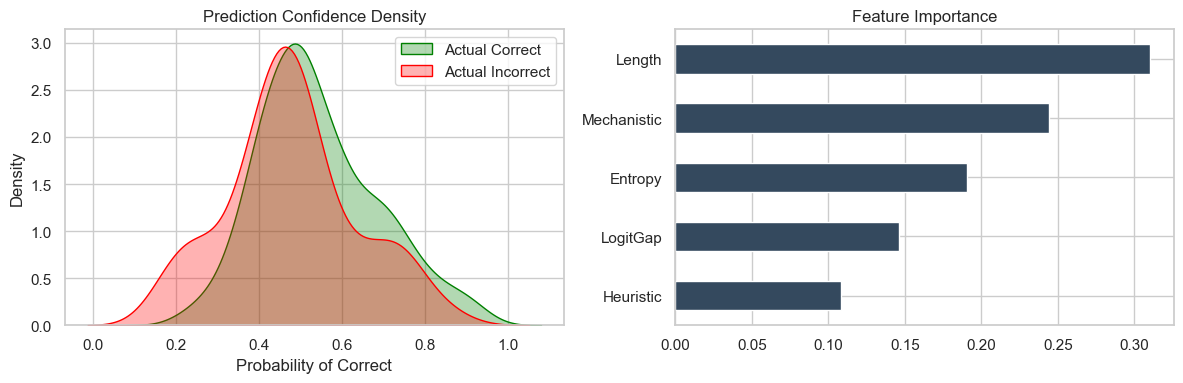

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_curve, auc

# --- 1. PREP & SPLIT ---
features = ['Entropy', 'LogitGap', 'Heuristic', 'Mechanistic', "Length"]
unique_questions = df['question_text'].unique()

train_q, test_q = train_test_split(unique_questions, test_size=0.5, random_state=42)
train_df = df[df['question_text'].isin(train_q)].copy()
test_df  = df[df['question_text'].isin(test_q)].copy()

scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[features].fillna(0))
X_test  = scaler.transform(test_df[features].fillna(0))
y_train, y_test = train_df['Correct'], test_df['Correct']

# --- 2. TRAIN & PREDICT ---
clf = RandomForestClassifier(n_estimators=50, max_depth=3, class_weight='balanced', random_state=42)
clf.fit(X_train, y_train)

probs = clf.predict_proba(X_test)[:, 1]

# Attach predictions back to the dataframe for inspection
test_df['Prob_Correct'] = probs
test_df['Pred_Label'] = (probs > 0.5).astype(int)

# --- 3. VISUALIZATION (Compact) ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.kdeplot(x=test_df[test_df['Correct']==1]['Prob_Correct'], fill=True, color='green', label='Actual Correct', alpha=0.3)
sns.kdeplot(x=test_df[test_df['Correct']==0]['Prob_Correct'], fill=True, color='red', label='Actual Incorrect', alpha=0.3)
plt.title('Prediction Confidence Density')
plt.xlabel('Probability of Correct')
plt.legend()

plt.subplot(1, 2, 2)
pd.Series(clf.feature_importances_, index=features).sort_values().plot(kind='barh', color='#34495e')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

# --- 4. QUALITATIVE VERIFICATION ---
def print_samples(title, subset, n=3):
    print(f"\n--- {title} (Showing {min(n, len(subset))}/{len(subset)}) ---")
    if len(subset) == 0:
        print("(No samples found in this category)")
        return
    
    # Sort by confidence to see the most egregious examples
    if "False Positive" in title: 
        # Model was sure it was Right (Prob high), but was Wrong
        subset = subset.sort_values('Prob_Correct', ascending=False)
    elif "False Negative" in title:
        # Model was sure it was Wrong (Prob low), but was Right
        subset = subset.sort_values('Prob_Correct', ascending=True)
        
    for i, (_, row) in enumerate(subset.head(n).iterrows()):
        print(f"[{i+1}] Conf: {row['Prob_Correct']:.2f} | Len: {row.get('Length', 'N/A')}")
        print(f"    Q: {str(row.get('question_text'))[:]}")
        print(f"    Trace Snippet: {str(row.get('full_trace_text'))[:]}")

# # 1. FALSE POSITIVES (Model said CORRECT, actually WRONG) - "Overconfident"
# fp = test_df[(test_df['Correct'] == 0) & (test_df['Pred_Label'] == 1)]
# print_samples("FALSE POSITIVES (Model Hallucinations?)", fp)

# # 2. FALSE NEGATIVES (Model said WRONG, actually CORRECT) - "Missed Gems"
# fn = test_df[(test_df['Correct'] == 1) & (test_df['Pred_Label'] == 0)]
# print_samples("FALSE NEGATIVES (Model Pessimism)", fn)

# # 3. TRUE NEGATIVES (Model said WRONG, actually WRONG) - "Correct Rejections"
# tn = test_df[(test_df['Correct'] == 0) & (test_df['Pred_Label'] == 0)]
# print_samples("TRUE NEGATIVES (Caught Failures)", tn)

In [10]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [10,50, 100],
    'max_depth': [2,3, 4, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced']
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)


{'class_weight': 'balanced', 'max_depth': 2, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


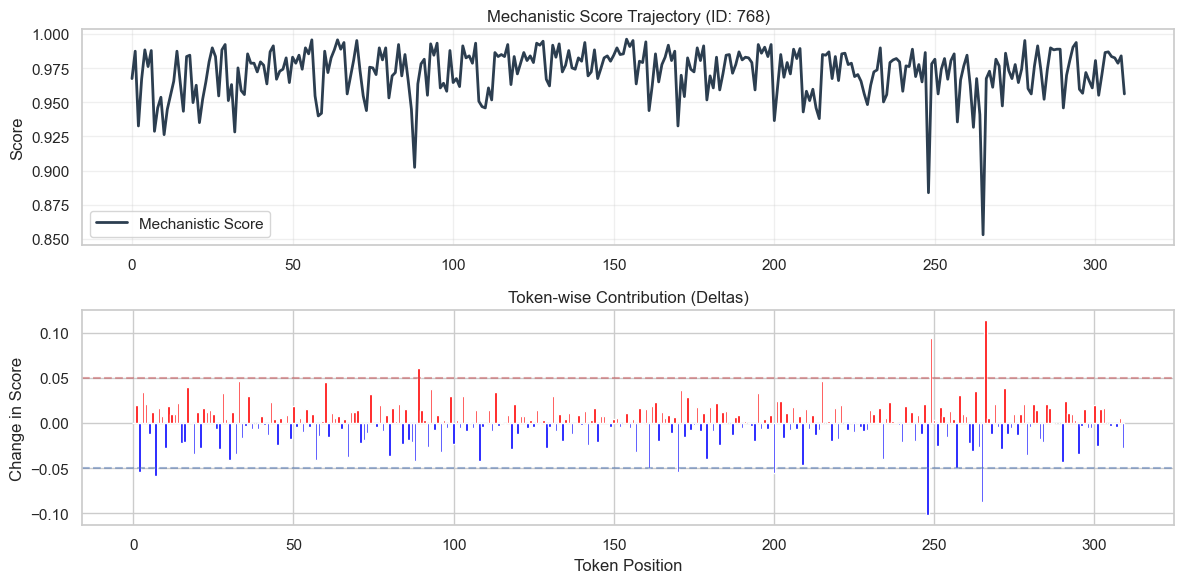


=== MAJOR SPIKES (> 0.05) ===
Pos   | Delta    | Score    | Token
---------------------------------------------
2     | -0.0547 🔻 | 0.9326   | " how"
7     | -0.0591 🔻 | 0.9287   | "as"
89    | +0.0610 🔺 | 0.9634   | ":"
161   | -0.0503 🔻 | 0.9438   | "}"
170   | -0.0547 🔻 | 0.9326   | "}"
200   | -0.0557 🔻 | 0.9365   | "}"
248   | -0.1025 🔻 | 0.8838   | "4"
249   | +0.0942 🔺 | 0.9780   | "\"
265   | -0.0879 🔻 | 0.8530   | "2"
266   | +0.1143 🔺 | 0.9673   | "\"


In [11]:
import sqlite3
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIG ---
DB_PATH = 'db/results.sqlite'
THRESHOLD = 0.05  # Highlight jumps larger than this (positive or negative)

def analyze_trace_spikes(result_id=None):
    conn = sqlite3.connect(DB_PATH)
    conn.row_factory = sqlite3.Row
    
    # 1. Fetch Data
    if result_id:
        query = "SELECT * FROM Results WHERE result_id = ?"
        params = (result_id,)
    else:
        query = "SELECT * FROM Results ORDER BY result_id DESC LIMIT 1"
        params = ()
        
    row = conn.execute(query, params).fetchone()
    conn.close()
    
    if not row:
        print("No data found.")
        return

    # 2. Parse JSON Traces
    try:
        mech_trace = json.loads(row['uq_mech_trace'])
        tokens = json.loads(row['uq_tokens']) # <--- NOW USING REAL TOKENS
        
        # Optional: Load others if needed
        # entropy_trace = json.loads(row['uq_entropy_trace'])
    except TypeError:
        print(f"Result {row['result_id']} does not have trace data (Legacy row?).")
        return
    except KeyError:
        print(f"Result {row['result_id']} is missing 'uq_tokens'. Did you run the schema update?")
        return

    # 3. Calculate Deltas (Spikes)
    # Delta[i] = Score[i] - Score[i-1]
    deltas = [0] + [mech_trace[i] - mech_trace[i-1] for i in range(1, len(mech_trace))]
    
    # 4. Visualization: The "Spike Graph"
    plt.figure(figsize=(12, 6))
    
    # Plot Raw Score
    plt.subplot(2, 1, 1)
    plt.plot(mech_trace, label='Mechanistic Score', color='#2c3e50', linewidth=2)
    plt.title(f"Mechanistic Score Trajectory (ID: {row['result_id']})")
    plt.ylabel("Score")
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Plot Deltas (The Spikes)
    plt.subplot(2, 1, 2)
    plt.bar(range(len(deltas)), deltas, color=['red' if d > 0 else 'blue' for d in deltas])
    plt.axhline(y=THRESHOLD, color='r', linestyle='--', alpha=0.5)
    plt.axhline(y=-THRESHOLD, color='b', linestyle='--', alpha=0.5)
    plt.title("Token-wise Contribution (Deltas)")
    plt.ylabel("Change in Score")
    plt.xlabel("Token Position")
    plt.tight_layout()
    plt.show()

    # 5. Text Alignment (Exact)
    print(f"\n=== MAJOR SPIKES (> {THRESHOLD}) ===")
    print(f"{'Pos':<5} | {'Delta':<8} | {'Score':<8} | {'Token'}")
    print("-" * 45)
    
    # Use the minimum length to avoid index errors if traces slightly mismatch (though they shouldn't now)
    limit = min(len(tokens), len(deltas))
    
    for i in range(limit):
        if abs(deltas[i]) >= THRESHOLD:
            indicator = "🔺" if deltas[i] > 0 else "🔻"
            
            # Clean up special token characters for readability
            # 'Ġ' is used by BPE (RoBERTa/GPT) to represent space
            # 'Ċ' represents newline
            token_str = str(tokens[i]).replace('Ġ', ' ').replace('Ċ', '\\n')
            
            print(f"{i:<5} | {deltas[i]:+.4f} {indicator} | {mech_trace[i]:.4f}   | \"{token_str}\"")

# --- RUN IT ---
# Analyze the most recent generation
analyze_trace_spikes()